In [3]:

from typing import List
from typing_extensions import TypedDict
from langchain.schema import Document
from database.get_vectordb import get_vectordb
from langgraph.graph import END, StateGraph, START
from llm_chian.rag_chain import get_rag_chain
from llm_chian.retrieval_grader import get_retrieval_grader
from llm_chian.question_re_writer import get_question_rewriter
from tool.search import get_web_search_tool




# 如果大模型觉得有必要让用户补充信息，与用户交互获得提示信息（）
# 创建管理系统用于添加新的文档


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

class GraphPoint():
    '''
        创建图中的结点
    '''
    # def __init__(self, api_key, search_type="similarity", search_kwargs={'k': 2},model = "qwen-max", temperature = 0) -> None:
    def __init__(self,retriever, rag_chain, retrieval_grader, question_rewriter, web_search_tool) -> None:
        """
            Args:
               
        """

        self.retriever = retriever
        self.rag_chain = rag_chain
        self.retrieval_grader = retrieval_grader
        self.question_rewriter = question_rewriter
        self.web_search_tool = web_search_tool
    
    async def retrieve(self, state):
        """
        Retrieve documents

        Args:
            state (dict):  

        Returns:
            state (dict): New key added to state, documents, that contains retrieved documents
        """
        print("---RETRIEVE---")
        question = state["question"]

        # Retrieval
        # documents = self.retriever.get_relevant_documents(question)
        documents = await self.retriever.search_docs(query=question)
        return {"documents": documents, "question": question}


    def generate(self, state):
        """
        Generate answer

        Args:
            state (dict): The current graph state

        Returns:
            state (dict): New key added to state, generation, that contains LLM generation
        """
        print("---GENERATE---")
        question = state["question"]
        documents = state["documents"]

        
        context = []
        for d in documents:
            context.append(d.page_content)

        # RAG generation
        generation = self.rag_chain.invoke({"context": str(context), "question": question})
        return {"documents": documents, "question": question, "generation": generation}


    def grade_documents(self,state):
        """
        判断检索到的文件是否与问题相关.在此处还要使用知识图谱进行扩充

        Args:
            state (dict): The current graph state

        Returns:
            state (dict): Updates documents key with only filtered relevant documents
        """

        print("---检查文档与检索到问题之间的相关性---")
        question = state["question"]
        documents = state["documents"]

        # Score each doc
        filtered_docs = []
        web_search = "No"
        for d in documents:
            score = self.retrieval_grader.invoke(
                {"question": question, "document": d.page_content}
            )
            
            if score :
                try:
                    # grade = score.binary_score # 使用在线大模型时的调用方法
                    grade = score.tool_calls[0]['args']['binary_score'] #使用chatollama时的获取方法
                    # print("=================grade====================")
                    # print(grade)
                    # print("=================grade====================")
                except:
                    grade = None
                
            else:
                grade = None
            if grade == "yes":
                print("---文本相关---")
                filtered_docs.append(d)
            else:
                print("---文本不相关---")
            if len(filtered_docs) == 0:
                web_search = "Yes"  
        return {"documents": filtered_docs, "question": question, "web_search": web_search}

    def transform_query(self, state):
        """
        Transform the query to produce a better question.

        Args:
            state (dict): The current graph state

        Returns:
            state (dict): Updates question key with a re-phrased question
        """

        print("---TRANSFORM QUERY---")
        question = state["question"]
        documents = state["documents"]

        # Re-write question
        better_question = self.question_rewriter.invoke({"question": question})
        # better_question = better_question.content #这是使用chatollama绑定工具后输出的格式， 如果更换别的大模型，可能需要更换代码编写方法
        # print('---------------------------------')
        # print(better_question)
        # print('---------------------------------')
        better_question = better_question.content
        return {"documents": documents, "question": better_question}


    def web_search(self, state):
        """
        Web search based on the re-phrased question.

        Args:
            state (dict): The current graph state

        Returns:
            state (dict): Updates documents key with appended web results
        """
        
        print("---WEB 搜索---")
        question = state["question"]
        documents = state["documents"]
        # Web search
        
        docs = self.web_search_tool.run(question)
        web_results = "\n".join([d for d in docs])
        web_results = Document(page_content=web_results)
        documents.append(web_results)

        # print("-----------web_results------------")
        # print(web_results)
        # print("-----------web_results------------")


        return {"documents": documents, "question": question}


    ### Edges


    def decide_to_generate(self, state):
        """
        Determines whether to generate an answer, or re-generate a question.

        Args:
            state (dict): The current graph state

        Returns:
            str: Binary decision for next node to call
        """

        print("---ASSESS GRADED DOCUMENTS---")
        state["question"]
        web_search = state["web_search"]
        state["documents"]

        if web_search == "Yes":
            # All documents have been filtered check_relevance
            # We will re-generate a new query
            print(
                "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
            )
            return "transform_query"
        else:
            # We have relevant documents, so generate answer
            print("---DECISION: GENERATE---")
            return "generate"
        
    def bulid_graph(self):
        workflow = StateGraph(GraphState)

        # Define the nodes
        workflow.add_node("retrieve", self.retrieve)  # retrieve
        workflow.add_node("grade_documents", self.grade_documents)  # grade documents
        workflow.add_node("generate", self.generate)  # generatae
        workflow.add_node("transform_query", self.transform_query)  # transform_query
        workflow.add_node("web_search_node", self.web_search)  # web search

        # Build graph
        workflow.add_edge(START, "retrieve")
        workflow.add_edge("retrieve", "grade_documents")
        workflow.add_conditional_edges(
            "grade_documents",
            self.decide_to_generate,
            {
                "transform_query": "transform_query",
                "generate": "generate",
            },
        )
        workflow.add_edge("transform_query", "web_search_node")
        workflow.add_edge("web_search_node", "generate")
        workflow.add_edge("generate", END)

        # Compile
        app = workflow.compile()

        return app
    

In [8]:
import os
import sys

os.environ['http_proxy'] = '127.0.0.1:7890'
os.environ['https_proxy'] = '127.0.0.1:7890'

import asyncio
from langgraph.graph import StateGraph, MessagesState, START, END
from typing import Literal
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import  AnyMessage, SystemMessage, HumanMessage, AIMessage,ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from llm_chian.model_to_llm import get_llm

from configs.model_config import TEMPERATURE, API_KEY

from database.get_vectordb import get_vectordb
from llm_chian.rag_chain import get_rag_chain
from llm_chian.retrieval_grader import get_retrieval_grader
from llm_chian.question_re_writer import get_question_rewriter
from tool.search import get_web_search_tool

# 创建检索器
from server.knowledge_base.kb_service.faiss_kb_service import FaissKBService



class AgentState(MessagesState):
    '''
        从MessagesState集成有messages: Annotated[list[AnyMessage], add_messages]
        所以这个类实际上包含两个字段
        messages: Annotated[list[AnyMessage], add_messages]
        next: str
    '''
    next: str




class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH"""
    # 节点名称
    next: Literal["chat", "ve_RAG", "FINISH"]

class MultiRAG():
    def __init__(self, model:str='qwen-max'):
        self.llm = get_llm(model = model, temperature = TEMPERATURE, api_key = API_KEY)
        self.members = ["chat", "ve_RAG"]
        self.options = self.members + ["FINISH"]
        
        retriever = FaissKBService("private")
        rag_chain = get_rag_chain(model = model, temperature = TEMPERATURE, api_key = API_KEY)
        retrieval_grader = get_retrieval_grader(model = model, temperature = TEMPERATURE, api_key = API_KEY)
        question_rewriter = get_question_rewriter(model = model, temperature = TEMPERATURE, api_key = API_KEY)
        web_search_tool = get_web_search_tool() 


        # 创veRAG智能体
        self.ve_RAG_graph = GraphPoint(retriever=retriever, rag_chain=rag_chain, retrieval_grader=retrieval_grader, question_rewriter=question_rewriter, web_search_tool=web_search_tool).bulid_graph()


    
    async def supervisor(self, state: AgentState):

        system_prompt = (
            "你是负责管理以下智能体的主管智能体："
            f"{self.members}。\n\n"
            "每个智能体都有特定的角色：\n"
            "- chat：使用自然语言直接回应用户输入。"
            "- ve_RAG：存储杭州逸检科技有限公司信息，包括公司简介、WeD系列仪分子诊断仪器等逸检科技出售的有关产品详细信息和使用说明，基于传统语义检索知识库构建，擅长回答详细且细致的问题。"
            "根据以下用户请求，指定下一位执行任务的智能体。\n"
            "每个智能体将执行任务并返回结果和状态。\n"
            "任务完成后，回复“FINISH\n"
        )

        messages = [{"role": "system", "content": system_prompt},] + state["messages"]

        response = await self.llm.with_structured_output(Router).ainvoke(messages)

        next_ = response["next"]
        
        if next_ == "FINISH":
            next_ = END
        
        return { "next": next_}


    async def chat(self, state: AgentState):
        messages = state["messages"]
        model_response = await self.llm.ainvoke(messages)
        final_response = [AIMessage(content=model_response.content, name="chat")]
        return {"messages": final_response}


    async def ve_RAG(self, state: AgentState):
    

        print('============state["messages"][-1]===========')
        print(state["messages"][-1].content)
        print('============state["messages"][-1]===========')

        result = await self.ve_RAG_graph.ainvoke({"question": state["messages"][-1].content})
        # for chunck in await self.ve_RAG_graph.ainvoke({"question": state["messages"][-1].content}):
        #     result.append(chunck)
        # result = await self.ve_RAG_graph.ainvo  ke({"question": state["messages"][-1].content})
        # return {"messages": [AIMessage(content=result.generation, name="ve_RAG")]}
        # print("=================result=======================")
        # print(type(result))
        # print(result['generation'])
        # print("================result=====================")
        
        return {"messages": [AIMessage(content=result['generation'], name="ve_RAG")]}
    

    def bulid_graph(self):

        
        builder = StateGraph(AgentState)

        # 添加开始和节点
        builder.add_edge(START, "supervisor")
        builder.add_node("supervisor", self.supervisor)
        builder.add_node("chat", self.chat)
        builder.add_node("ve_RAG", self.ve_RAG_graph)


        for member in self.members:
            # 我们希望我们的工人在完成工作后总是向主管智能体“汇报”
            builder.add_edge(member, "supervisor")
        
        # 在图状态中填充next字段，路由到具体的某个节点或者结束图的运行，指定如何执行接下来的任务
        builder.add_conditional_edges("supervisor", lambda state: state["next"])

        # 添加开始和节点
        # builder.add_edge(START, "supervisor")

        # builder.add_edge(START, "chat")
        # 在创建任何 LangGraph 图时，通过在编译图时添加MemorySaver来将其设置为保留其State状态中的数据
        memory = MemorySaver()
        # 编译图
        graph = builder.compile(checkpointer = memory)
        return graph
   





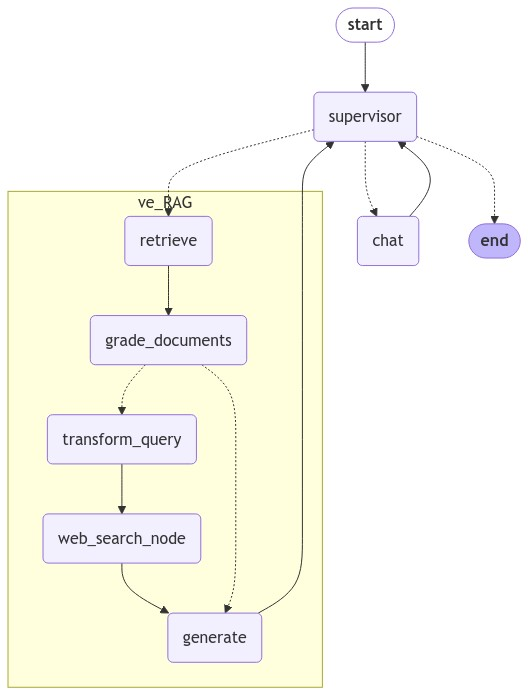

In [9]:
def main():
    tmp = MultiRAG()
    graph = tmp.bulid_graph()
    from IPython.display import Image, display
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
if __name__ == "__main__":
    main()






In [7]:
# 导入检查点
from typing import Annotated
from langgraph.checkpoint.memory import MemorySaver
import os
from langgraph.graph.message import add_messages



llm = ChatOpenAI(
                api_key='sk-83f939a7ee424d588c176662a9636061',
                base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
                model='qwen-max',
)


class State(TypedDict):
    messages: Annotated[list, add_messages]

def call_model(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": response}

def translate_message(state: State):
    system_prompt = """
    Please translate the received text in any language into English as output
    """
    messages = state['messages'][-1]
    messages = [SystemMessage(content=system_prompt)] + [HumanMessage(content=messages.content)]
    response = llm.invoke(messages)
    return {"messages": response}

builder = StateGraph(State)

builder.add_node("call_model", call_model)
builder.add_node("translate_message", translate_message)

builder.add_edge(START, "call_model")
builder.add_edge("call_model", "translate_message")
builder.add_edge("translate_message", END)


memory = MemorySaver()
graph_with_memory = builder.compile(checkpointer=memory)   # 在编译图的时候添加检查点



In [2]:
user_id = "test_user"
content = f"当前与程序对话的用户ID为:{user_id}"
print(content)

当前与程序对话的用户ID为:{user_id}


In [19]:
# 这个 thread_id 可以取任意数值
config = {"configurable": {"thread_id": "1"}}

async for chunk in graph_with_memory.astream({"messages": ["你好，我叫木羽"]}, config, stream_mode="values"):
    print(chunk)
    print()

{'messages': [HumanMessage(content='你好，我叫木羽', id='471fe661-c92f-4bb3-94c3-cba55172d5c7'), AIMessage(content='你好，木羽！很高兴认识你。有什么我可以帮助你的吗？', response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 14, 'total_tokens': 29, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'qwen-max', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run-0004b834-54af-4132-afdb-4e31c2d63e5e-0', usage_metadata={'input_tokens': 14, 'output_tokens': 15, 'total_tokens': 29}), AIMessage(content='Hello, Mu Yu! Nice to meet you. Is there anything I can help you with?', response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 43, 'total_tokens': 62, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'qwen-max', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run-fd165572-7dc5-40a1-94d8-95d1be41789b-0', usage_metadata={'input_tokens': 43, 'output_tokens': 19, 'total_tokens': 62}), HumanMessage(content=

In [21]:
async for chunk in graph_with_memory.astream({"messages": ["请问我叫什么？"]}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='你好，我叫木羽', id='471fe661-c92f-4bb3-94c3-cba55172d5c7'), AIMessage(content='你好，木羽！很高兴认识你。有什么我可以帮助你的吗？', response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 14, 'total_tokens': 29, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'qwen-max', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run-0004b834-54af-4132-afdb-4e31c2d63e5e-0', usage_metadata={'input_tokens': 14, 'output_tokens': 15, 'total_tokens': 29}), AIMessage(content='Hello, Mu Yu! Nice to meet you. Is there anything I can help you with?', response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 43, 'total_tokens': 62, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'qwen-max', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run-fd165572-7dc5-40a1-94d8-95d1be41789b-0', usage_metadata={'input_tokens': 43, 'output_tokens': 19, 'total_tokens': 62}), HumanMessage(content=

In [ ]:
from graph.multi_crag import MultiRAG

